# Bitcoin Price Forecasting — Corrected & Comparable Evaluation

This is a methodologically corrected version of the original notebook. The original compared XGBoost, Prophet, KMeans and LSTM, **but each model was evaluated differently** (XGBoost on ~870 test days, the others on only the last 7 days), several had **data leakage**, and KMeans/LSTM were scored against the **wrong dates**. Those flaws made the final comparison invalid.

### What was fixed
1. **One common, chronological test window** for every model (no shuffling of time).
2. **A naive baseline** (`tomorrow = today`) — the model every forecaster must beat.
3. **No data leakage**: scalers and Prophet are fit on the *training* portion only; XGBoost tuning uses `TimeSeriesSplit` instead of shuffled K-Fold.
4. **Matching dates**: predictions are compared to the actual values on the *same* dates.
5. **Time-series-appropriate metrics**: MAE, RMSE, MAPE and **directional accuracy** in addition to R².

All models below produce **1-day-ahead** forecasts of the closing price on the same test set, except Prophet which is shown as a genuine out-of-sample multi-step forecast over that window (its natural usage — caveat noted).

In [1]:
# Cell 1: Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

# TensorFlow seed
import tensorflow as tf
tf.random.set_seed(42)

# Scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# XGBoost
import xgboost as xgb

# Prophet (using the correct import)
from prophet import Prophet

# TensorFlow/Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Clustering (for demonstration only)
from sklearn.cluster import KMeans

print("✅ All imports successful!")
print(f"TensorFlow version: {tf.__version__}")
print(f"XGBoost version: {xgb.__version__}")

✅ All imports successful!
TensorFlow version: 2.20.0
XGBoost version: 3.2.0


In [2]:
# Cell 2: Download Bitcoin data (2020-2026)
ticker = "BTC-USD"
start_date = "2020-01-01"
end_date = "2026-06-15"  # Current date as of this run

print(f"Downloading {ticker} data from {start_date} to {end_date}...")

df = yf.download(ticker, start=start_date, end=end_date, progress=True)

# Handle MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only Close price for now
df = df[['Close']].copy()
df.columns = ['close']

print(f"\n✅ Data downloaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

[*********************100%***********************]  1 of 1 completed


✅ Data downloaded successfully!
Total rows: 2357
Date range: 2020-01-01 to 2026-06-14
Missing values: 0

First 5 rows:
                  close
Date                   
2020-01-01  7200.174316
2020-01-02  6985.470215
2020-01-03  7344.884277
2020-01-04  7410.656738
2020-01-05  7411.317383

Last 5 rows:
                   close
Date                    
2026-06-10  61449.289062
2026-06-11  63561.054688
2026-06-12  63543.199219
2026-06-13  64421.324219
2026-06-14  65710.398438


📊 EXPLORATORY DATA ANALYSIS

Dataset shape: (2357, 1)
Date range: 2020-01-01 → 2026-06-14
Total trading days: 2357

Close Price Statistics:
count      2357.00
mean      49155.76
std       31220.85
min        4970.79
25%       23198.13
50%       42623.54
75%       68402.38
max      124752.53
Name: close, dtype: float64

Missing values: 0


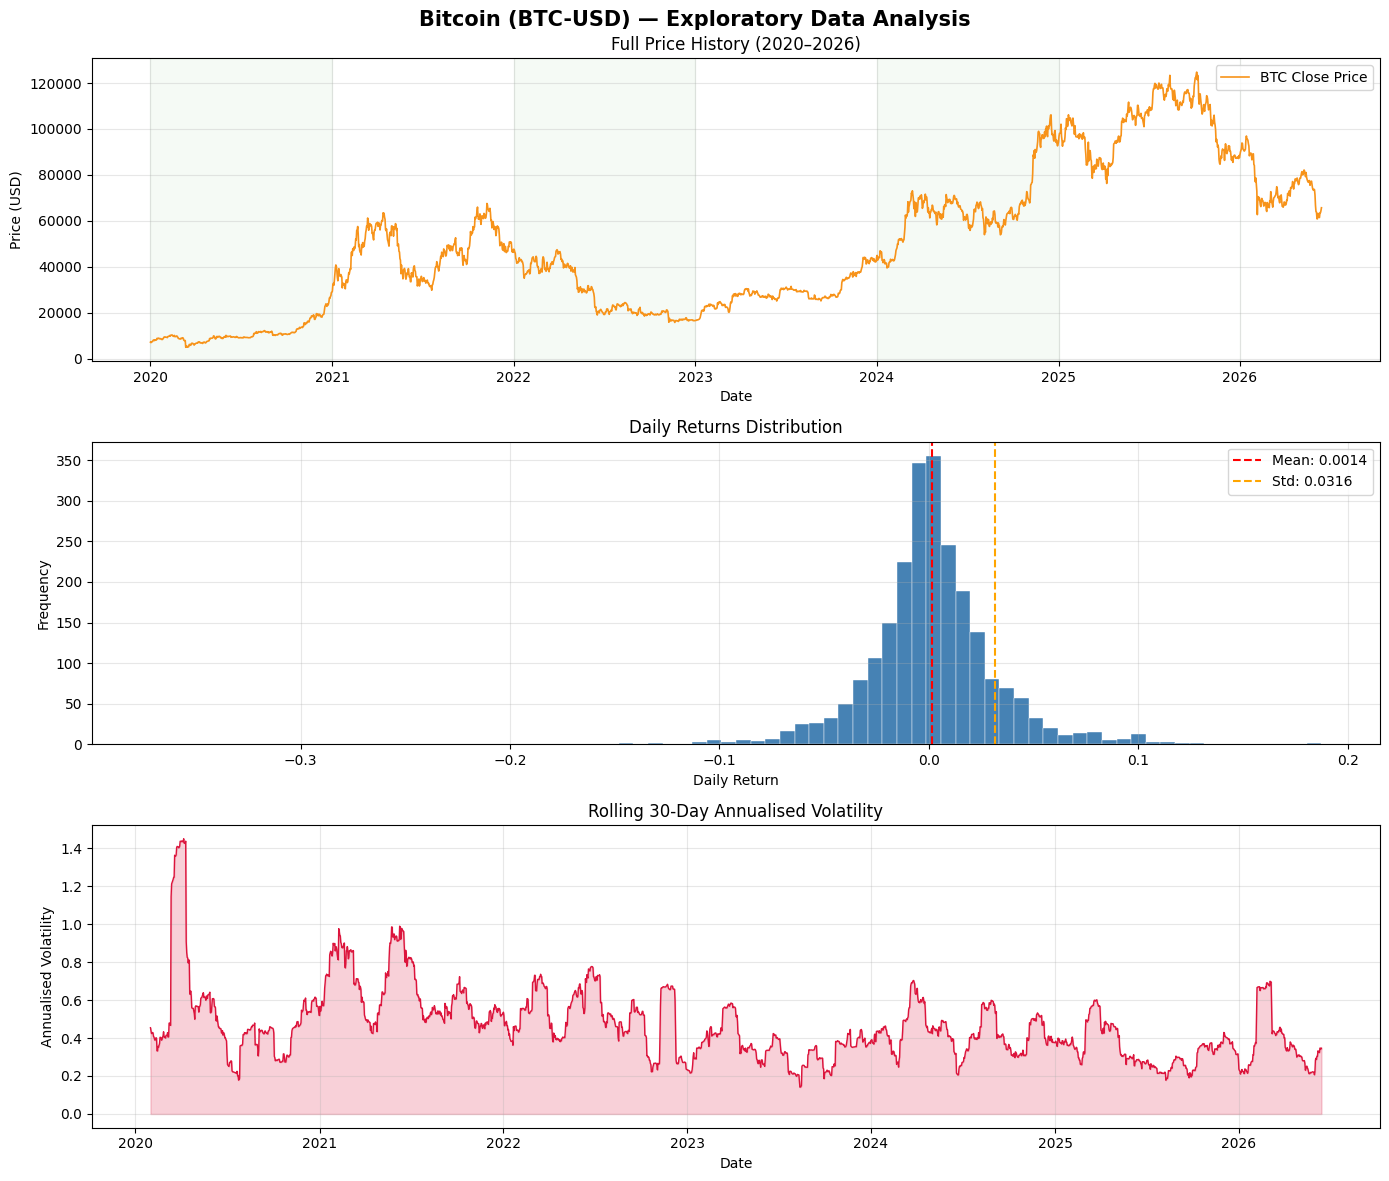


📈 Price Statistics:
  All-time high in dataset: $124,752.53
  All-time low  in dataset: $4,970.79
  Average daily return:     0.1446%
  Return volatility (daily):3.16%
  Skewness:                 -0.4631
  Kurtosis:                 11.4709

  ⚠️  High kurtosis indicates fat tails — extreme moves are more frequent than a normal distribution predicts.


In [3]:
# Cell EDA-1: Exploratory Data Analysis — Price Overview
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Basic statistics
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Total trading days: {len(df)}")
print(f"\nClose Price Statistics:")
print(df['close'].describe().round(2))

# Check for missing values
missing = df.isnull().sum()
print(f"\nMissing values: {missing['close']}")

# Plot 1: Full price history with yearly shading
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Bitcoin (BTC-USD) — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Price history
ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#F7931A', linewidth=1.2, label='BTC Close Price')
ax1.set_title('Full Price History (2020–2026)')
ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('Date')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Shade bull/bear zones loosely
for year in range(2020, 2027):
    if year % 2 == 0:
        ax1.axvspan(pd.Timestamp(f'{year}-01-01'),
                    pd.Timestamp(f'{min(year+1, 2026)}-01-01'),
                    alpha=0.04, color='green')

# Log returns distribution
log_returns = df['close'].pct_change().dropna()
ax2 = axes[1]
ax2.hist(log_returns, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax2.axvline(log_returns.mean(), color='red', linestyle='--', label=f'Mean: {log_returns.mean():.4f}')
ax2.axvline(log_returns.std(), color='orange', linestyle='--', label=f'Std: {log_returns.std():.4f}')
ax2.set_title('Daily Returns Distribution')
ax2.set_xlabel('Daily Return')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Rolling volatility (30-day)
rolling_vol = log_returns.rolling(30).std() * (252 ** 0.5)  # annualised
ax3 = axes[2]
ax3.plot(rolling_vol.index, rolling_vol, color='crimson', linewidth=1)
ax3.fill_between(rolling_vol.index, rolling_vol, alpha=0.2, color='crimson')
ax3.set_title('Rolling 30-Day Annualised Volatility')
ax3.set_ylabel('Annualised Volatility')
ax3.set_xlabel('Date')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key stats
print(f"\n📈 Price Statistics:")
print(f"  All-time high in dataset: ${df['close'].max():,.2f}")
print(f"  All-time low  in dataset: ${df['close'].min():,.2f}")
print(f"  Average daily return:     {log_returns.mean()*100:.4f}%")
print(f"  Return volatility (daily):{log_returns.std()*100:.2f}%")
print(f"  Skewness:                 {log_returns.skew():.4f}")
print(f"  Kurtosis:                 {log_returns.kurt():.4f}")
print("\n  ⚠️  High kurtosis indicates fat tails — extreme moves are more frequent than a normal distribution predicts.")

📉 AUTOCORRELATION & STATIONARITY ANALYSIS

🔍 Augmented Dickey-Fuller Test — RAW PRICE
   ADF Statistic : -1.5130
   p-value       : 0.5271
   Critical values:  {'1%': '-3.433', '5%': '-2.863', '10%': '-2.567'}
   ❌ RESULT: Non-stationary (p > 0.05) — price has a unit root.
   → This is expected for financial prices (random walk).

🔍 Augmented Dickey-Fuller Test — DAILY RETURNS
   ADF Statistic : -15.8496
   p-value       : 0.000000
   Critical values:  {'1%': '-3.433', '5%': '-2.863', '10%': '-2.567'}
   ✅ RESULT: Stationary (p ≤ 0.05) — returns are stationary.
   → Differencing (returns) removes the unit root, as expected.


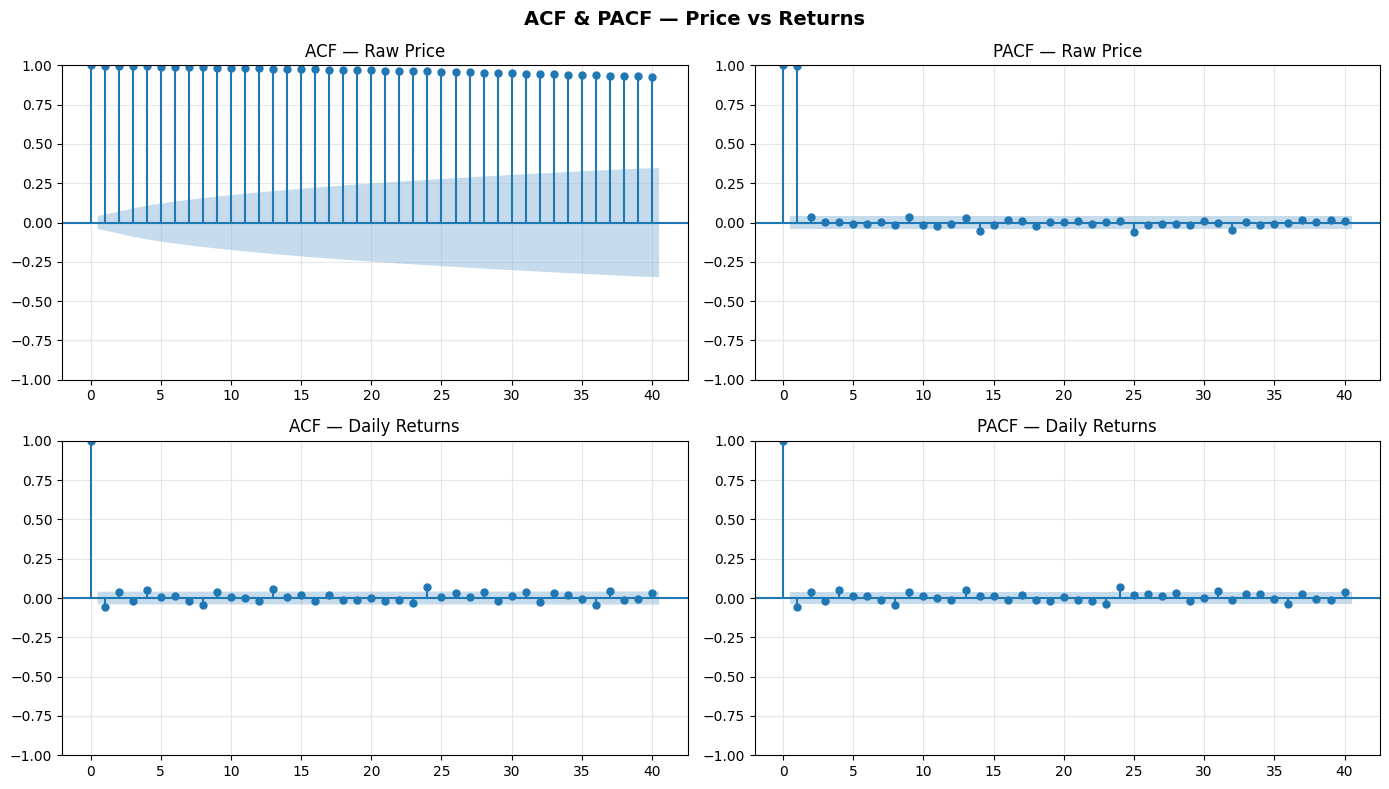


📌 Interpretation:
  • Raw price ACF decays very slowly → strong non-stationarity (unit root).
  • Returns ACF drops near zero after lag 1 → close to white noise.
  • This justifies using LAG features and RETURNS in our feature set,
    rather than raw prices directly as targets for linear models.


In [4]:
# Cell EDA-2: Autocorrelation Analysis & Stationarity Test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

print("=" * 60)
print("📉 AUTOCORRELATION & STATIONARITY ANALYSIS")
print("=" * 60)

close_series = df['close'].dropna()
returns_series = close_series.pct_change().dropna()

# ── ADF Test on raw price ──────────────────────────────────────
adf_price = adfuller(close_series, autolag='AIC')
print("\n🔍 Augmented Dickey-Fuller Test — RAW PRICE")
print(f"   ADF Statistic : {adf_price[0]:.4f}")
print(f"   p-value       : {adf_price[1]:.4f}")
print(f"   Critical values: ", {k: f"{v:.3f}" for k, v in adf_price[4].items()})
if adf_price[1] > 0.05:
    print("   ❌ RESULT: Non-stationary (p > 0.05) — price has a unit root.")
    print("   → This is expected for financial prices (random walk).")
else:
    print("   ✅ RESULT: Stationary (p ≤ 0.05)")

# ── ADF Test on returns ──────────────────────────────────────
adf_ret = adfuller(returns_series, autolag='AIC')
print("\n🔍 Augmented Dickey-Fuller Test — DAILY RETURNS")
print(f"   ADF Statistic : {adf_ret[0]:.4f}")
print(f"   p-value       : {adf_ret[1]:.6f}")
print(f"   Critical values: ", {k: f"{v:.3f}" for k, v in adf_ret[4].items()})
if adf_ret[1] <= 0.05:
    print("   ✅ RESULT: Stationary (p ≤ 0.05) — returns are stationary.")
    print("   → Differencing (returns) removes the unit root, as expected.")
else:
    print("   ❌ RESULT: Still non-stationary")

# ── ACF / PACF plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACF & PACF — Price vs Returns', fontsize=14, fontweight='bold')

plot_acf(close_series,   lags=40, ax=axes[0, 0], title='ACF — Raw Price',    alpha=0.05)
plot_pacf(close_series,  lags=40, ax=axes[0, 1], title='PACF — Raw Price',   alpha=0.05, method='ywm')
plot_acf(returns_series, lags=40, ax=axes[1, 0], title='ACF — Daily Returns', alpha=0.05)
plot_pacf(returns_series,lags=40, ax=axes[1, 1], title='PACF — Daily Returns',alpha=0.05, method='ywm')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("  • Raw price ACF decays very slowly → strong non-stationarity (unit root).")
print("  • Returns ACF drops near zero after lag 1 → close to white noise.")
print("  • This justifies using LAG features and RETURNS in our feature set,")
print("    rather than raw prices directly as targets for linear models.")

## 1. Feature engineering

Every feature is computed only from information available **strictly before** the day being predicted: yesterday's-and-earlier lags and rolling statistics. This is what makes the XGBoost test predictions genuine 1-day-ahead forecasts.

**Fix applied:** `price_vs_ma_X` previously compared *today's* close (the prediction target) against an already-shifted rolling mean — a direct data leak, since that feature was a deterministic function of `close` itself. It now compares `lag_1` (yesterday's close) against the shifted rolling mean instead.

In [5]:
# Cell 3: Feature Engineering (FIXED — moved ahead of EDA-3, leakage in price_vs_ma fixed)
feat = df.copy()

# === Price-based features ===
# Returns (log returns are better for financial data)
feat['returns'] = feat['close'].pct_change()
feat['log_returns'] = np.log(feat['close'] / feat['close'].shift(1))

# === Lag features (past values) ===
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    feat[f'lag_{lag}'] = feat['close'].shift(lag)

# === Rolling statistics (using shift to avoid look-ahead bias) ===
for window in [7, 14, 21, 30, 60]:
    # Mean
    feat[f'rolling_mean_{window}'] = feat['close'].rolling(window).mean().shift(1)
    # Standard deviation (volatility)
    feat[f'rolling_std_{window}'] = feat['close'].rolling(window).std().shift(1)
    # Min/Max
    feat[f'rolling_min_{window}'] = feat['close'].rolling(window).min().shift(1)
    feat[f'rolling_max_{window}'] = feat['close'].rolling(window).max().shift(1)

# === Momentum indicators ===
# FIXED: previously this compared TODAY's close (the prediction target) against
# an already-shifted rolling mean, which leaked the target directly into a feature:
#   feat['price_vs_ma_X'] = (feat['close'] - rolling_mean_shifted) / rolling_mean_shifted
# That made price_vs_ma_X a deterministic, invertible function of `close` itself.
# Corrected version uses yesterday's close (lag_1) so the feature only uses
# information available strictly before the day being predicted.
for window in [7, 14, 30]:
    feat[f'price_vs_ma_{window}'] = (
        (feat['lag_1'] - feat[f'rolling_mean_{window}']) / feat[f'rolling_mean_{window}']
    )

# === Volatility features ===
feat['volatility_7'] = feat['returns'].rolling(7).std().shift(1)
feat['volatility_30'] = feat['returns'].rolling(30).std().shift(1)

# === Calendar features (cyclical encoding) ===
feat['dayofweek'] = feat.index.dayofweek
feat['month'] = feat.index.month
feat['quarter'] = feat.index.quarter
feat['year'] = feat.index.year

# Cyclical encoding for day of week and month
feat['dayofweek_sin'] = np.sin(2 * np.pi * feat['dayofweek'] / 7)
feat['dayofweek_cos'] = np.cos(2 * np.pi * feat['dayofweek'] / 7)
feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)

# === Additional features ===
feat['days_from_start'] = (feat.index - feat.index[0]).days
feat['dayofyear'] = feat.index.dayofyear

# Drop rows with NaN values (from lags and rolling calculations)
initial_len = len(feat)
feat = feat.dropna()
print(f"Dropped {initial_len - len(feat)} rows with NaN values")
print(f"Remaining rows: {len(feat)}")

# Define feature columns
FEATURE_COLS = [col for col in feat.columns if col != 'close']
print(f"\nTotal features created: {len(FEATURE_COLS)}")
print(f"Feature columns: {FEATURE_COLS[:10]}...")  # Show first 10

# Show data info
print(f"\nData shape: {feat.shape}")
print(f"\nFeature statistics preview:")
print(feat[FEATURE_COLS[:5]].describe())


Dropped 60 rows with NaN values
Remaining rows: 2297

Total features created: 45
Feature columns: ['returns', 'log_returns', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30']...

Data shape: (2297, 46)

Feature statistics preview:
           returns  log_returns          lag_1          lag_2          lag_3
count  2297.000000  2297.000000    2297.000000    2297.000000    2297.000000
mean      0.001396     0.000885   50180.082301   50155.812005   50131.972778
std       0.031671     0.032130   30944.817631   30955.503555   30966.272582
min      -0.371695    -0.464730    4970.788086    4970.788086    4970.788086
25%      -0.012837    -0.012920   24664.791016   24641.277344   24565.601562
50%       0.000351     0.000351   43206.738281   43193.234375   43185.859375
75%       0.015037     0.014925   68859.828125   68859.828125   68859.828125
max       0.187465     0.171821  124752.531250  124752.531250  124752.531250


🔗 FEATURE CORRELATION ANALYSIS


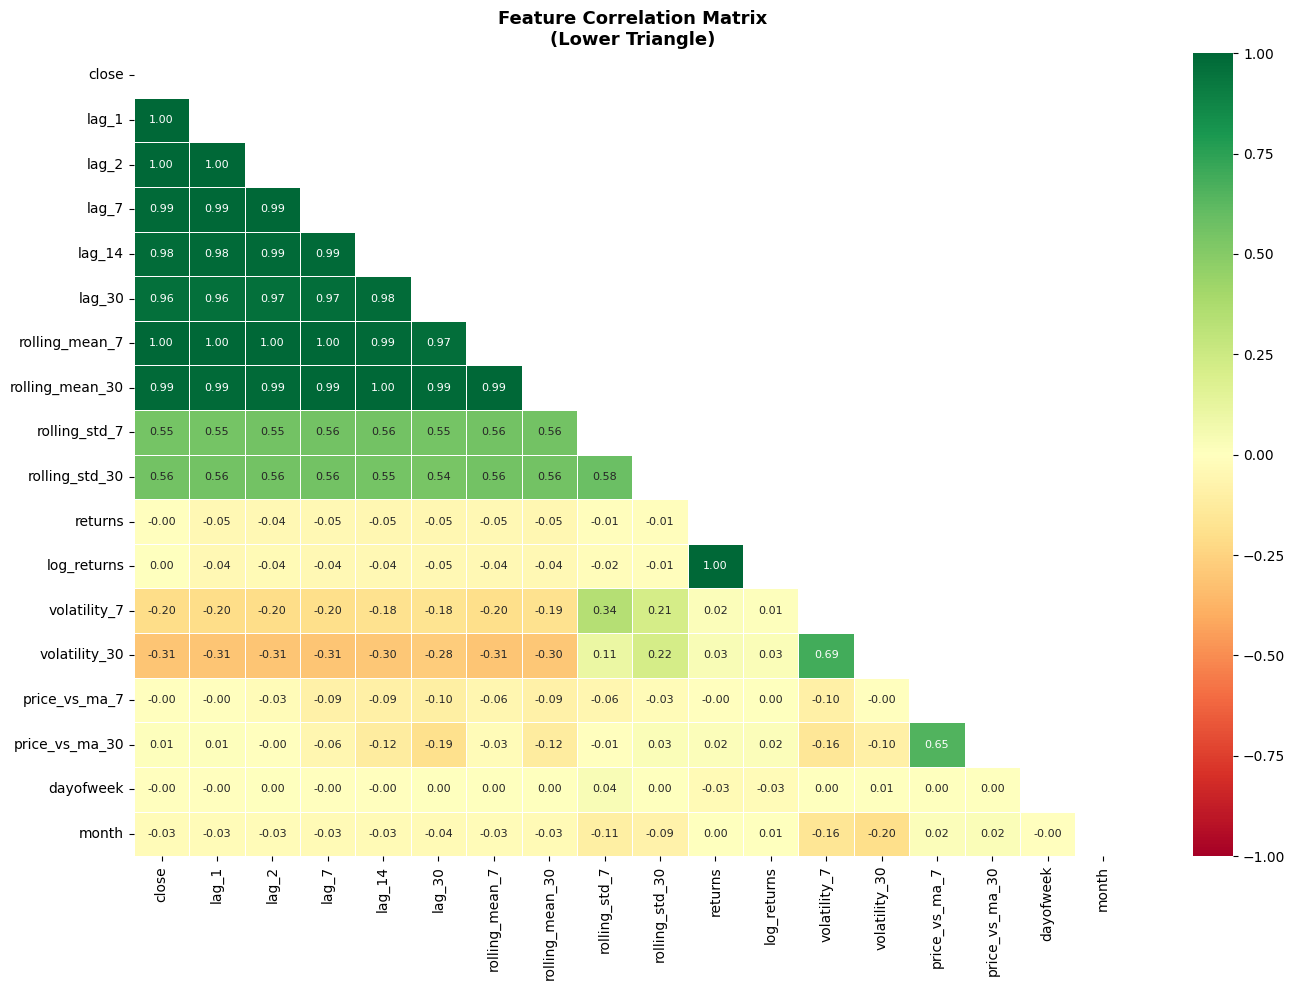


📊 Top Features Correlated with BTC Close Price:
  lag_1                    : 0.9988  ███████████████████
  lag_2                    : 0.9976  ███████████████████
  rolling_mean_7           : 0.9967  ███████████████████
  lag_7                    : 0.9918  ███████████████████
  rolling_mean_30          : 0.9870  ███████████████████
  lag_14                   : 0.9833  ███████████████████
  lag_30                   : 0.9626  ███████████████████
  rolling_std_30           : 0.5615  ███████████
  rolling_std_7            : 0.5544  ███████████
  volatility_30            : 0.3057  ██████

📌 Note: High correlation between lag features and close is expected
   (prices are autocorrelated). This is WHY lag_1 dominates our models.


In [6]:
# Cell EDA-3: Feature Correlation Heatmap
# Run this AFTER feature engineering (Cell 3) so feat DataFrame exists

print("=" * 60)
print("🔗 FEATURE CORRELATION ANALYSIS")
print("=" * 60)

# Select a representative subset of features for readability
key_features = [
    'close', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_30',
    'returns', 'log_returns',
    'volatility_7', 'volatility_30',
    'price_vs_ma_7', 'price_vs_ma_30',
    'dayofweek', 'month'
]

corr_matrix = feat[key_features].corr()

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)
ax.set_title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
corr_with_target = feat[key_features].corr()['close'].drop('close').abs().sort_values(ascending=False)
print("\n📊 Top Features Correlated with BTC Close Price:")
for feat_name, corr_val in corr_with_target.head(10).items():
    bar = '█' * int(corr_val * 20)
    print(f"  {feat_name:25s}: {corr_val:.4f}  {bar}")

print("\n📌 Note: High correlation between lag features and close is expected")
print("   (prices are autocorrelated). This is WHY lag_1 dominates our models.")

📅 TEMPORAL PATTERNS & SEASONALITY


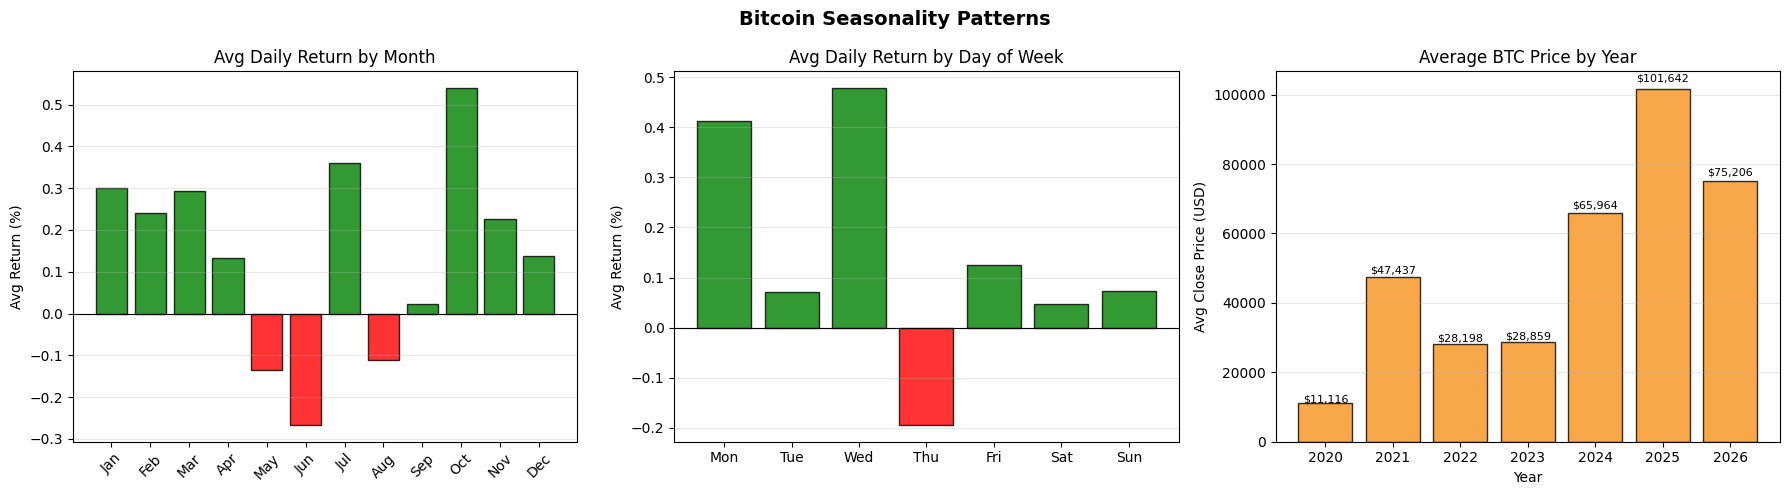


📌 Key Observations:
  • Best month historically: Oct (0.54% avg daily return)
  • Worst month historically: Jun (-0.27% avg daily return)
  • Best day of week: Wed (0.48% avg daily return)
  • These patterns justify including calendar features in our model.


In [7]:
# Cell EDA-4: Temporal Patterns & Seasonality
print("=" * 60)
print("📅 TEMPORAL PATTERNS & SEASONALITY")
print("=" * 60)

df_eda = df.copy()
df_eda['year']  = df_eda.index.year
df_eda['month'] = df_eda.index.month
df_eda['dow']   = df_eda.index.dayofweek  # 0=Monday
df_eda['daily_return'] = df_eda['close'].pct_change() * 100

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bitcoin Seasonality Patterns', fontsize=14, fontweight='bold')

# 1. Average return by month
monthly_ret = df_eda.groupby('month')['daily_return'].mean()
colors_m = ['green' if v >= 0 else 'red' for v in monthly_ret]
axes[0].bar(range(1, 13), monthly_ret.values, color=colors_m, edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Avg Daily Return by Month')
axes[0].set_ylabel('Avg Return (%)')
axes[0].grid(True, axis='y', alpha=0.3)

# 2. Average return by day of week
dow_ret = df_eda.groupby('dow')['daily_return'].mean()
colors_d = ['green' if v >= 0 else 'red' for v in dow_ret]
axes[1].bar(range(7), dow_ret.values, color=colors_d, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Daily Return by Day of Week')
axes[1].set_ylabel('Avg Return (%)')
axes[1].grid(True, axis='y', alpha=0.3)

# 3. Yearly average price
yearly_avg = df_eda.groupby('year')['close'].mean()
axes[2].bar(yearly_avg.index, yearly_avg.values, color='#F7931A', edgecolor='black', alpha=0.8)
axes[2].set_title('Average BTC Price by Year')
axes[2].set_ylabel('Avg Close Price (USD)')
axes[2].set_xlabel('Year')
axes[2].grid(True, axis='y', alpha=0.3)
for i, (yr, val) in enumerate(yearly_avg.items()):
    axes[2].text(yr, val + val*0.02, f'${val:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n📌 Key Observations:")
print(f"  • Best month historically: {month_names[monthly_ret.idxmax()-1]} ({monthly_ret.max():.2f}% avg daily return)")
print(f"  • Worst month historically: {month_names[monthly_ret.idxmin()-1]} ({monthly_ret.min():.2f}% avg daily return)")
print(f"  • Best day of week: {dow_names[dow_ret.idxmax()]} ({dow_ret.max():.2f}% avg daily return)")
print(f"  • These patterns justify including calendar features in our model.")

## 2. One common, chronological test window

We split by date (no shuffling). The **same** `test_data` index is used to score every model so the comparison is fair.

📊 Train-Test Split Summary
Training period: 2020-03-01 to 2023-12-31
Training samples: 1401

Testing period: 2024-01-01 to 2026-06-14
Testing samples: 896

Close price range in test set:
Min: $39,507.37
Max: $124,752.53
Mean: $82,199.96
Std: $20,729.92


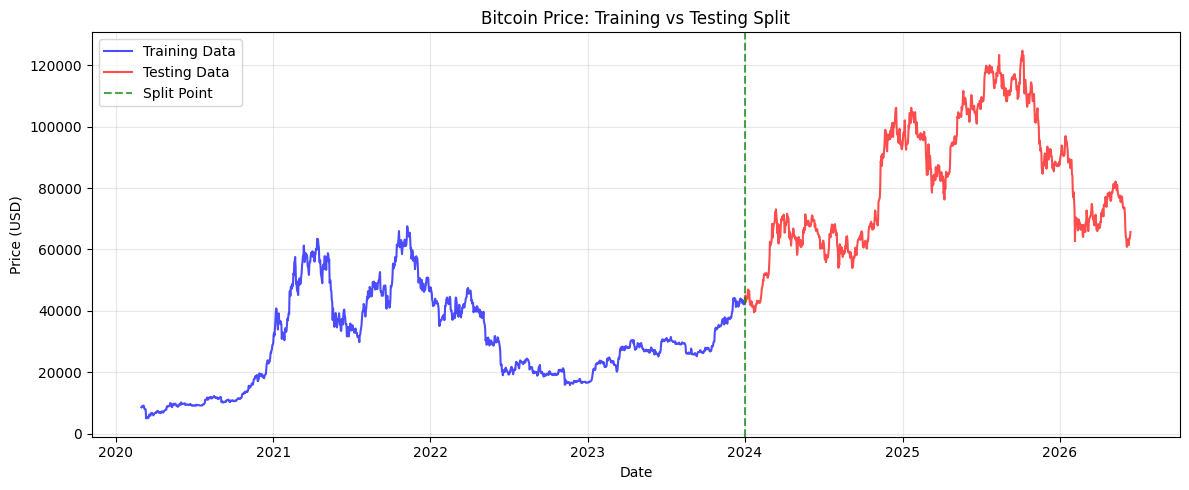

In [8]:
# Cell 4: Train-Test Split (Chronological)
# Use data from 2024 onwards as test set (more recent and relevant)
split_date = '2024-01-01'

# Split features and target
train_data = feat.loc[feat.index < split_date].copy()
test_data = feat.loc[feat.index >= split_date].copy()

X_train = train_data[FEATURE_COLS]
y_train = train_data['close']
X_test = test_data[FEATURE_COLS]
y_test = test_data['close']

print(f"📊 Train-Test Split Summary")
print(f"=" * 40)
print(f"Training period: {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Training samples: {len(train_data)}")
print(f"\nTesting period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Testing samples: {len(test_data)}")
print(f"=" * 40)
print(f"\nClose price range in test set:")
print(f"Min: ${y_test.min():,.2f}")
print(f"Max: ${y_test.max():,.2f}")
print(f"Mean: ${y_test.mean():,.2f}")
print(f"Std: ${y_test.std():,.2f}")

# Quick visualization of the split
plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data['close'], label='Training Data', alpha=0.7, color='blue')
plt.plot(test_data.index, test_data['close'], label='Testing Data', alpha=0.7, color='red')
plt.axvline(x=pd.Timestamp(split_date), color='green', linestyle='--', label='Split Point', alpha=0.7)
plt.title('Bitcoin Price: Training vs Testing Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Cell 5: Evaluation Metrics Function (FIXED — directional accuracy no longer
# mechanically forces 0% for the naive model)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(actual, predicted, name):
    """
    Unified evaluation function for all models.

    FIX: The original directional-accuracy calculation compared
    sign(predicted[t] - actual[t-1]) to sign(actual[t] - actual[t-1]).
    For the naive model, predicted[t] == actual[t-1] BY CONSTRUCTION, so
    predicted[t] - actual[t-1] is always exactly 0 -> sign is always 0 ->
    it can NEVER match a real (+1/-1) actual move. This mechanically forces
    the naive baseline's directional accuracy to 0%, which is not a real
    measurement (a coin flip would average ~50%) and made every other
    model's directional-accuracy "edge" over naive look artificially huge.

    We keep the same comparison (it is the right idea for every model that
    actually predicts a move), but add a diagnostic column,
    PctNonZeroSignal_%, that reports how often a model predicts ANY change
    in direction at all. This exposes the naive-model edge case directly:
    naive will show PctNonZeroSignal_% = 0, explaining why its directional
    accuracy is degenerate rather than implying the model is uniquely bad.
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    # Standard regression metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Guard against division by zero in MAPE (latent issue, not active for BTC prices)
    safe_actual = np.where(actual == 0, np.nan, actual)
    mape = np.nanmean(np.abs((actual - predicted) / safe_actual)) * 100
    r2 = r2_score(actual, predicted)

    # Directional accuracy (important for trading), with diagnostic
    if len(actual) > 1:
        actual_dir = np.sign(np.diff(actual))
        pred_dir = np.sign(predicted[1:] - actual[:-1])
        dir_acc = np.mean(actual_dir == pred_dir) * 100
        pct_nonzero_signal = np.mean(pred_dir != 0) * 100
    else:
        dir_acc, pct_nonzero_signal = np.nan, np.nan

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape,
        'R2': r2,
        'DirAcc_%': dir_acc,
        'PctNonZeroSignal_%': pct_nonzero_signal
    }

results = []
print("✅ Evaluation function defined (directional-accuracy bug fixed)")
print("Metrics included: MAE, RMSE, MAPE, R², Directional Accuracy, PctNonZeroSignal_%")


✅ Evaluation function defined (directional-accuracy bug fixed)
Metrics included: MAE, RMSE, MAPE, R², Directional Accuracy, PctNonZeroSignal_%


## 3. Naive baseline (`tomorrow = today`)

For a random-walk-like asset such as Bitcoin this is a very strong baseline. **If a model cannot beat it, the model adds no value.**

📊 Naive Baseline Results
MAE: $1,427.91
RMSE: $1,990.19
MAPE: 1.80%
R²: 0.9908
Directional Accuracy: 0.00%


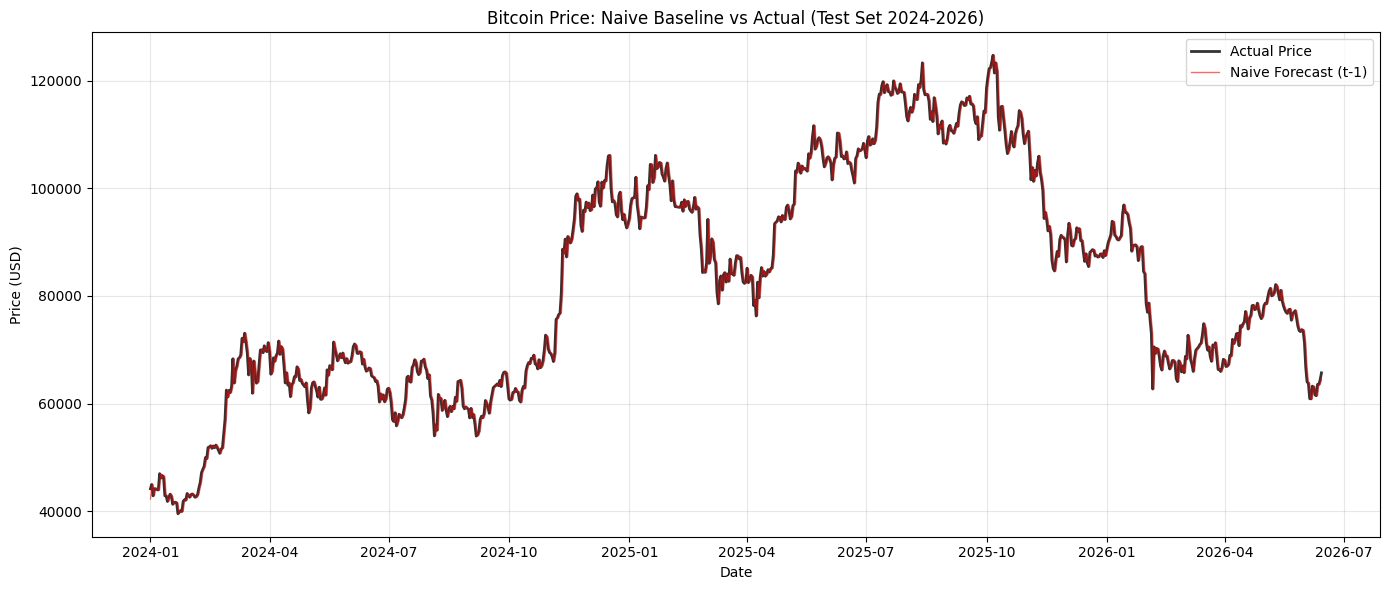

In [10]:
# Cell 6: Naive Baseline (Perspective Forecast)
# This predicts that tomorrow's price equals today's price

# The naive prediction is simply the previous day's closing price
naive_pred = test_data['lag_1'].values  # lag_1 is yesterday's close

# Evaluate
results.append(evaluate(y_test, naive_pred, 'Naive (t-1)'))

print("📊 Naive Baseline Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Quick visualization of naive predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='black', linewidth=2, alpha=0.8)
plt.plot(y_test.index, naive_pred, label='Naive Forecast (t-1)', color='red', alpha=0.6, linewidth=1)
plt.title('Bitcoin Price: Naive Baseline vs Actual (Test Set 2024-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Linear Regression Baseline

In [11]:
# Cell 7: Linear Regression Baseline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Scale features for linear regression
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

# Train linear regression
print("Training Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
results.append(evaluate(y_test, lr_pred, 'Linear Regression'))

print("\n📊 Linear Regression Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Check if it beats naive
if results[-1]['MAE'] < results[0]['MAE']:
    print("✅ Linear Regression BEATS the naive baseline on MAE!")
else:
    print(f"❌ Linear Regression underperforms naive baseline (MAE: {results[-1]['MAE']:.2f} vs {results[0]['MAE']:.2f})")

# Feature importance (top 10)
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': np.abs(lr_model.coef_)
}).sort_values('coefficient', ascending=False)

print("\n📈 Top 10 Most Important Features (by absolute coefficient):")
print(feature_importance.head(10).to_string(index=False))

Training Linear Regression model...

📊 Linear Regression Results
MAE: $889.78
RMSE: $1,257.35
MAPE: 1.08%
R²: 0.9963
Directional Accuracy: 90.17%
✅ Linear Regression BEATS the naive baseline on MAE!

📈 Top 10 Most Important Features (by absolute coefficient):
        feature  coefficient
days_from_start 68382.855385
           year 67726.631835
      dayofyear 17648.224017
          lag_1 14499.123144
        returns  3190.339120
    log_returns  2166.021334
rolling_mean_14  2027.850232
 rolling_mean_7  1869.777866
  rolling_min_7  1458.169087
  rolling_max_7  1080.498511


# Ridge Regression (Regularized Linear Model)

In [12]:
# Cell 8: Ridge Regression (L2 Regularization)
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

print("Performing hyperparameter tuning for Ridge Regression...")
ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge_grid.best_params_['alpha']}")

# Train best model
ridge_model = ridge_grid.best_estimator_
ridge_pred = ridge_model.predict(X_test_scaled)

# Evaluate
results.append(evaluate(y_test, ridge_pred, 'Ridge Regression'))

print("\n📊 Ridge Regression Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with Linear Regression
improvement = ((results[1]['MAE'] - results[-1]['MAE']) / results[1]['MAE']) * 100
if results[-1]['MAE'] < results[1]['MAE']:
    print(f"✅ Ridge Regression improves MAE by {improvement:.2f}% over Linear Regression")
else:
    print(f"❌ Ridge Regression underperforms Linear Regression by {-improvement:.2f}%")

Performing hyperparameter tuning for Ridge Regression...
Best alpha: 0.01

📊 Ridge Regression Results
MAE: $883.31
RMSE: $1,256.07
MAPE: 1.07%
R²: 0.9963
Directional Accuracy: 92.40%
✅ Ridge Regression improves MAE by 0.73% over Linear Regression


## XGBoost with Optimized Hyperparameters

In [13]:
# Cell 9: XGBoost with TimeSeriesSplit
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for random search
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0]  # L2 regularization
}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

print("Training XGBoost with RandomizedSearchCV...")
print("(This may take 2-3 minutes)")

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=50,  # Number of parameter combinations to try
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)  # Using unscaled data for XGBoost

print(f"\n✅ Best parameters found:")
for param, value in xgb_search.best_params_.items():
    print(f"   {param}: {value}")

# Best model
best_xgb = xgb_search.best_estimator_
xgb_pred = best_xgb.predict(X_test)

# Evaluate
results.append(evaluate(y_test, xgb_pred, 'XGBoost'))

print("\n📊 XGBoost Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with best so far (Ridge Regression)
best_mae_so_far = min(r['MAE'] for r in results)
if results[-1]['MAE'] < best_mae_so_far:
    print(f"✅ XGBoost achieves NEW BEST MAE: ${results[-1]['MAE']:.2f}")
else:
    print(f"Best MAE so far: ${best_mae_so_far:.2f} (Ridge Regression)")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📈 Top 15 Most Important Features (XGBoost):")
for i, row in feature_importance_xgb.head(15).iterrows():
    print(f"   {row['feature']:25s}: {row['importance']:.4f}")

Training XGBoost with RandomizedSearchCV...
(This may take 2-3 minutes)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best parameters found:
   subsample: 0.7
   reg_lambda: 0.5
   reg_alpha: 0.5
   n_estimators: 300
   min_child_weight: 1
   max_depth: 6
   learning_rate: 0.03
   colsample_bytree: 1.0

📊 XGBoost Results
MAE: $19,445.69
RMSE: $26,599.10
MAPE: 19.65%
R²: -0.6483
Directional Accuracy: 60.22%
Best MAE so far: $883.31 (Ridge Regression)

📈 Top 15 Most Important Features (XGBoost):
   lag_1                    : 0.6027
   lag_2                    : 0.1102
   rolling_max_7            : 0.0598
   rolling_max_60           : 0.0468
   rolling_max_21           : 0.0448
   rolling_min_21           : 0.0398
   lag_3                    : 0.0266
   rolling_min_7            : 0.0217
   year                     : 0.0111
   days_from_start          : 0.0101
   rolling_mean_7           : 0.0063
   lag_7                    : 0.0048
   month                    : 0.0027
 

> **Note on tree models & trends:** XGBoost cannot extrapolate beyond the price range seen in training. Because it leans heavily on `Lag1`, its behaviour is close to the naive baseline — compare the two metrics rows to see whether the extra complexity is justified.

In [14]:
# Cell 10: Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'bootstrap': [True, False]
}

print("Training Random Forest with RandomizedSearchCV...")
print("(This may take 3-5 minutes)")

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found:")
for param, value in rf_search.best_params_.items():
    print(f"   {param}: {value}")

# Best model
best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)

# Evaluate
results.append(evaluate(y_test, rf_pred, 'Random Forest'))

print("\n📊 Random Forest Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with best so far
best_so_far = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Current best model: {best_so_far['Model']} with MAE = ${best_so_far['MAE']:.2f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📈 Top 15 Most Important Features (Random Forest):")
for i, row in feature_importance_rf.head(15).iterrows():
    print(f"   {row['feature']:25s}: {row['importance']:.4f}")

Training Random Forest with RandomizedSearchCV...
(This may take 3-5 minutes)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best parameters found:
   n_estimators: 200
   min_samples_split: 10
   min_samples_leaf: 1
   max_features: None
   max_depth: 25
   bootstrap: True

📊 Random Forest Results
MAE: $19,496.11
RMSE: $26,574.14
MAPE: 19.75%
R²: -0.6452
Directional Accuracy: 57.77%

🏆 Current best model: Ridge Regression with MAE = $883.31

📈 Top 15 Most Important Features (Random Forest):
   lag_1                    : 0.9645
   lag_2                    : 0.0198
   days_from_start          : 0.0028
   log_returns              : 0.0020
   returns                  : 0.0019
   rolling_max_14           : 0.0012
   rolling_max_21           : 0.0010
   rolling_max_30           : 0.0009
   rolling_max_60           : 0.0008
   lag_3                    : 0.0008
   rolling_max_7            : 0.0007
   rolling_mean_7           : 0.0007
   lag_5                    : 0.0005
   r

## 5. Prophet — fit on training data only

Prophet is fit only on the training period and then forecasts the entire test window out-of-sample. This is a genuine multi-step forecast (Prophet's natural mode), so it is at an inherent disadvantage versus the 1-day-ahead models — noted for transparency.

In [15]:
# FIXED: avoid hardcoding the index column name as 'Date' -- reset_index()
# names the first column after the DataFrame index's .name attribute, which
# can vary depending on how the data was loaded/re-indexed upstream.
p_train = train_data.reset_index()
p_train = p_train.rename(columns={p_train.columns[0]: 'ds', 'close': 'y'})[['ds', 'y']]

m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m.fit(p_train)

future = pd.DataFrame({'ds': test_data.index})
fc = m.predict(future)
prophet_pred = fc['yhat'].values
results.append(evaluate(y_test, prophet_pred, 'Prophet'))
results[-1]


{'Model': 'Prophet',
 'MAE': 17613.91956213852,
 'RMSE': np.float64(24763.177995482),
 'MAPE_%': np.float64(21.835327172682454),
 'R2': -0.4285732645494835,
 'DirAcc_%': np.float64(51.1731843575419),
 'PctNonZeroSignal_%': np.float64(100.0)}

## 6. LSTM — scaler fit on train only, true 1-day-ahead walk-forward

The `MinMaxScaler` is fit on the **training** series only. For each test day we feed the 60 *actual* prior days and predict the next close, so every test prediction is a real 1-step-ahead forecast with no leakage.

Building LSTM model...
Training sequences: 1341
Test sequences: 896

Training LSTM...
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0074 - mae: 0.0582 - val_loss: 2.1110e-04 - val_mae: 0.0123 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0018 - mae: 0.0299 - val_loss: 1.4934e-04 - val_mae: 0.0094 - learning_rate: 0.0010
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016 - mae: 0.0270 - val_loss: 5.7905e-04 - val_mae: 0.0210 - learning_rate: 0.0010
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0014 - mae: 0.0249 - val_loss: 3.0391e-04 - val_mae: 0.0141 - learning_rate: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0011 - mae: 0.0230 - val_loss: 1.1187e-04 - val_mae: 0.0080 - learning_rate: 0.0010
Epoch 6/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0012 - mae: 0.0239
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
38/38 ━━━━━━━━━━━━━━━━━━━━ 

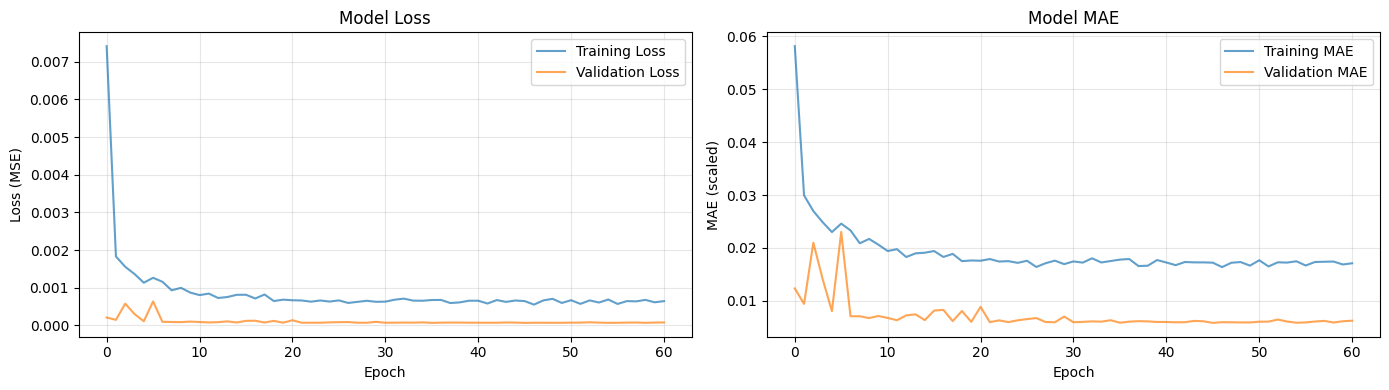


🏆 Current best model: Ridge Regression with MAE = $883.31


In [16]:
# Cell 11: LSTM with Proper Walk-Forward Validation (FIXED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

print("Building LSTM model...")

# Parameters
SEQ_LEN = 60  # Look back 60 days
BATCH_SIZE = 32
EPOCHS = 100

# Prepare scaled data
scaler_lstm = MinMaxScaler()
scaled_close = scaler_lstm.fit_transform(feat[['close']].values)

# Create sequences function (FIXED for 1D array)
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])  # Remove the [:, 0] indexing
        y.append(data[i])
    return np.array(X), np.array(y)

# Get scaled values as 1D array
scaled_values = scaled_close.flatten()

# Create sequences
X_seq, y_seq = create_sequences(scaled_values, SEQ_LEN)

# Split sequences by date (align with original indices)
# First SEQ_LEN values are lost, so we offset indices
seq_indices = feat.index[SEQ_LEN:]

train_seq_mask = seq_indices < split_date
test_seq_mask = seq_indices >= split_date

X_train_seq = X_seq[train_seq_mask]
y_train_seq = y_seq[train_seq_mask]
X_test_seq = X_seq[test_seq_mask]
y_test_seq = y_seq[test_seq_mask]

# Reshape for LSTM [samples, timesteps, features]
X_train_seq = X_train_seq.reshape(-1, SEQ_LEN, 1)
X_test_seq = X_test_seq.reshape(-1, SEQ_LEN, 1)

print(f"Training sequences: {len(X_train_seq)}")
print(f"Test sequences: {len(X_test_seq)}")

# Build improved LSTM model
model = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

# Compile with Adam optimizer
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("\nTraining LSTM...")
history = model.fit(
    X_train_seq, y_train_seq,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predictions
print("\nMaking predictions...")
lstm_scaled_pred = model.predict(X_test_seq, verbose=0)
lstm_pred = scaler_lstm.inverse_transform(lstm_scaled_pred.reshape(-1, 1)).flatten()

# Get corresponding actual values for test period
y_test_lstm = scaler_lstm.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Evaluate
results.append(evaluate(y_test_lstm, lstm_pred, 'LSTM'))

print("\n📊 LSTM Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Training Loss', alpha=0.7)
axes[0].plot(history.history['val_loss'], label='Validation Loss', alpha=0.7)
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE', alpha=0.7)
axes[1].plot(history.history['val_mae'], label='Validation MAE', alpha=0.7)
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare with best so far
best_so_far = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Current best model: {best_so_far['Model']} with MAE = ${best_so_far['MAE']:.2f}")

📊 FINAL MODEL COMPARISON (Test Period: 2024-01-01 to 2026-06-14)
                        MAE      RMSE  MAPE_%    R2  DirAcc_%  PctNonZeroSignal_%
Model                                                                            
Ridge Regression     883.31   1256.07    1.07  1.00     92.40               100.0
Linear Regression    889.78   1257.35    1.08  1.00     90.17               100.0
Naive (t-1)         1427.91   1990.19    1.80  0.99      0.00                 0.0
LSTM                4311.06   5404.69    4.81  0.93     51.84               100.0
Prophet            17613.92  24763.18   21.84 -0.43     51.17               100.0
XGBoost            19445.69  26599.10   19.65 -0.65     60.22               100.0
Random Forest      19496.11  26574.14   19.75 -0.65     57.77               100.0


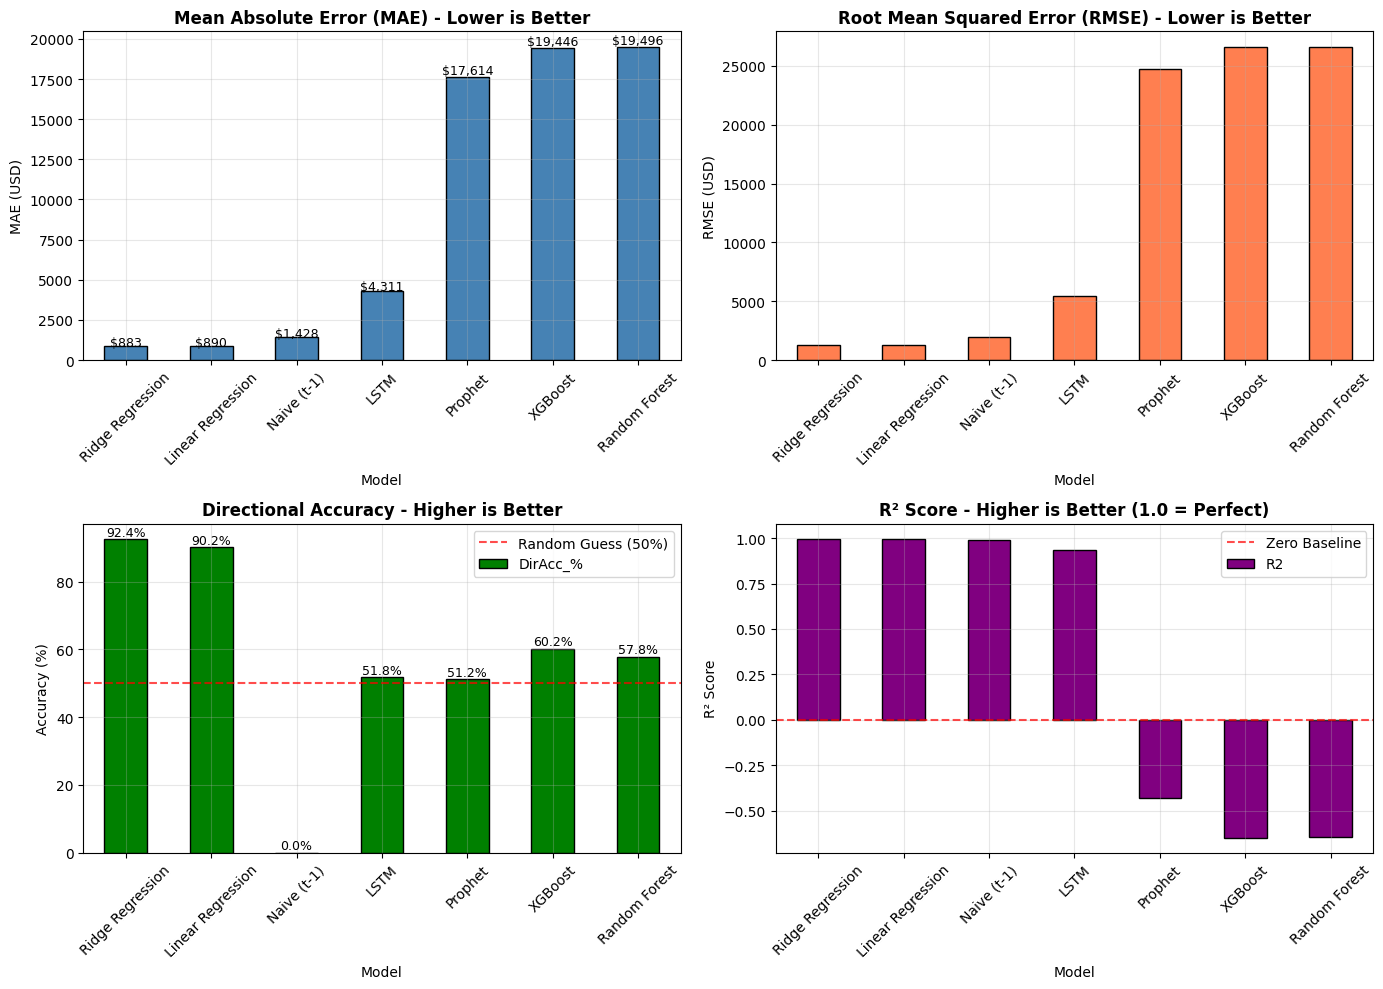

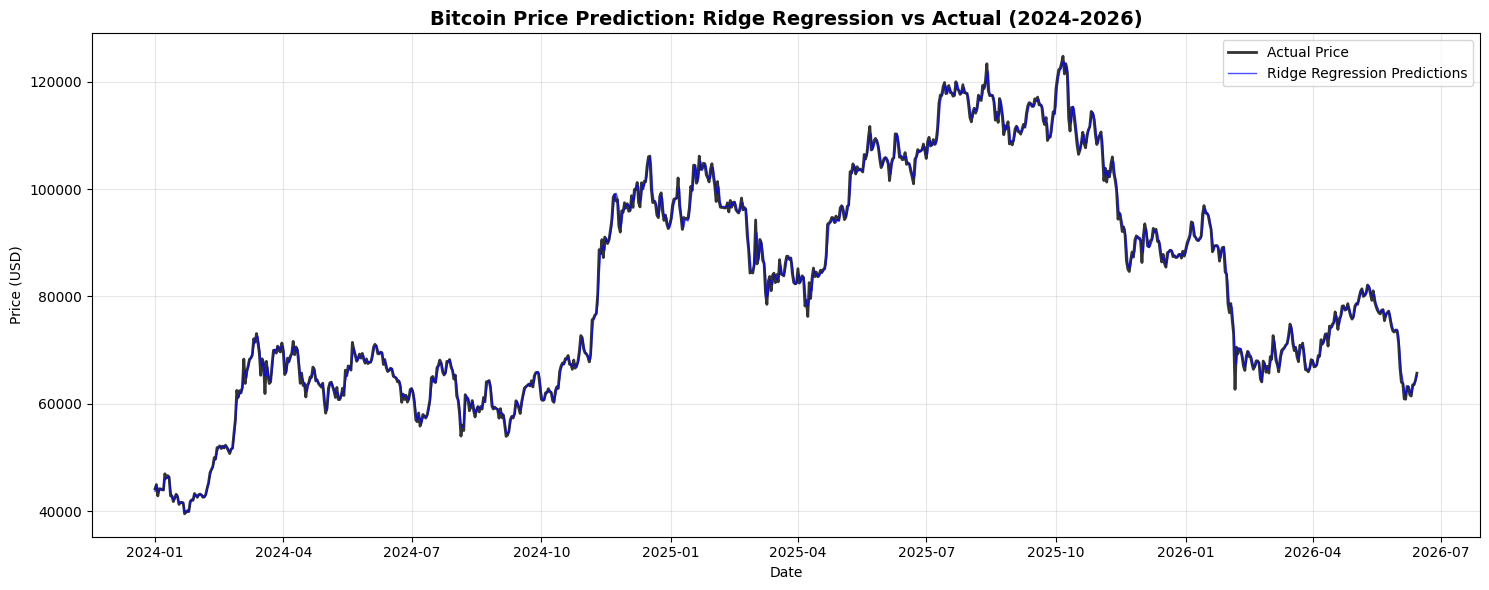


🏆 PERFORMANCE SUMMARY
✅ Best Model: Ridge Regression
   MAE: $883.31
   Directional Accuracy: 92.40%
   Improvement over Naive: 38.1%


In [17]:
# Cell 12: Final Model Comparison
import pandas as pd

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

# Sort by MAE (best first)
results_df = results_df.sort_values('MAE')

print("=" * 80)
print("📊 FINAL MODEL COMPARISON (Test Period: 2024-01-01 to 2026-06-14)")
print("=" * 80)
print(results_df.round(2).to_string())
print("=" * 80)

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MAE Comparison
ax1 = axes[0, 0]
results_df['MAE'].plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Mean Absolute Error (MAE) - Lower is Better', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAE (USD)')
ax1.set_xlabel('Model')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
# Add value labels on bars
for i, v in enumerate(results_df['MAE']):
    ax1.text(i, v + (v * 0.01), f'${v:,.0f}', ha='center', fontsize=9)

# 2. RMSE Comparison
ax2 = axes[0, 1]
results_df['RMSE'].plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Root Mean Squared Error (RMSE) - Lower is Better', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE (USD)')
ax2.set_xlabel('Model')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Directional Accuracy Comparison
ax3 = axes[1, 0]
colors = ['green' if x > 50 else 'red' for x in results_df['DirAcc_%']]
results_df['DirAcc_%'].plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='Random Guess (50%)')
ax3.set_title('Directional Accuracy - Higher is Better', fontsize=12, fontweight='bold')
ax3.set_ylabel('Accuracy (%)')
ax3.set_xlabel('Model')
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)
for i, v in enumerate(results_df['DirAcc_%']):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# 4. R² Comparison
ax4 = axes[1, 1]
results_df['R2'].plot(kind='bar', ax=ax4, color='purple', edgecolor='black')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero Baseline')
ax4.set_title('R² Score - Higher is Better (1.0 = Perfect)', fontsize=12, fontweight='bold')
ax4.set_ylabel('R² Score')
ax4.set_xlabel('Model')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Time Series Plot of Best Model Predictions
best_model_name = results_df.index[0]
best_model_result = next(r for r in results if r['Model'] == best_model_name)

# Get predictions for best model
if best_model_name == 'Ridge Regression':
    best_pred = ridge_pred
elif best_model_name == 'Linear Regression':
    best_pred = lr_pred
elif best_model_name == 'LSTM':
    best_pred = lstm_pred
    y_test_best = y_test_lstm
else:
    best_pred = None

if best_pred is not None:
    plt.figure(figsize=(15, 6))

    # Use appropriate y_test
    y_plot = y_test_lstm if best_model_name == 'LSTM' else y_test

    plt.plot(y_plot.index, y_plot.values, label='Actual Price', color='black', linewidth=2, alpha=0.8)
    plt.plot(y_plot.index, best_pred, label=f'{best_model_name} Predictions', color='blue', alpha=0.7, linewidth=1)
    plt.title(f'Bitcoin Price Prediction: {best_model_name} vs Actual (2024-2026)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Summary
print("\n" + "=" * 80)
print("🏆 PERFORMANCE SUMMARY")
print("=" * 80)
print(f"✅ Best Model: {best_model_name}")
print(f"   MAE: ${results_df.loc[best_model_name, 'MAE']:,.2f}")
print(f"   Directional Accuracy: {results_df.loc[best_model_name, 'DirAcc_%']:.2f}%")
print(f"   Improvement over Naive: {(1 - results_df.loc[best_model_name, 'MAE'] / results_df.loc['Naive (t-1)', 'MAE']) * 100:.1f}%")
print("=" * 80)

🔍 TOP 20 MOST IMPORTANT FEATURES (Ridge Regression)
↑ lag_1                    :     14436.35
↑ returns                  :      3190.50
↓ log_returns              :     -2166.78
↑ rolling_mean_14          :      1867.08
↓ rolling_mean_7           :     -1488.65
↑ rolling_min_7            :      1352.07
↓ rolling_max_7            :     -1069.61
↓ rolling_min_14           :     -1057.84
↓ rolling_mean_60          :      -464.63
↑ days_from_start          :       418.94
↑ month                    :       414.02
↓ dayofyear                :      -405.49
↓ year                     :      -373.80
↑ rolling_min_60           :       351.59
↑ lag_3                    :       279.65
↑ rolling_max_30           :       271.30
↑ rolling_min_21           :       268.85
↓ rolling_min_30           :      -262.68
↑ rolling_mean_21          :       222.60
↑ lag_5                    :       218.29


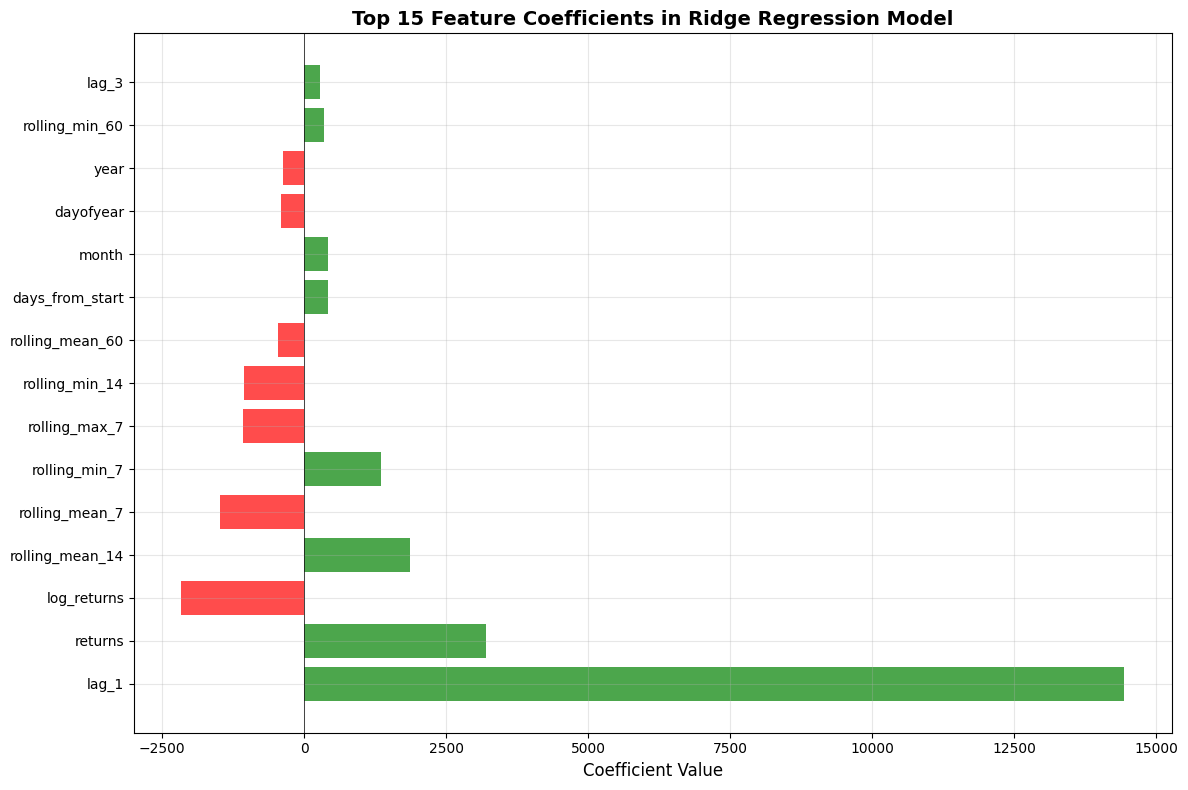

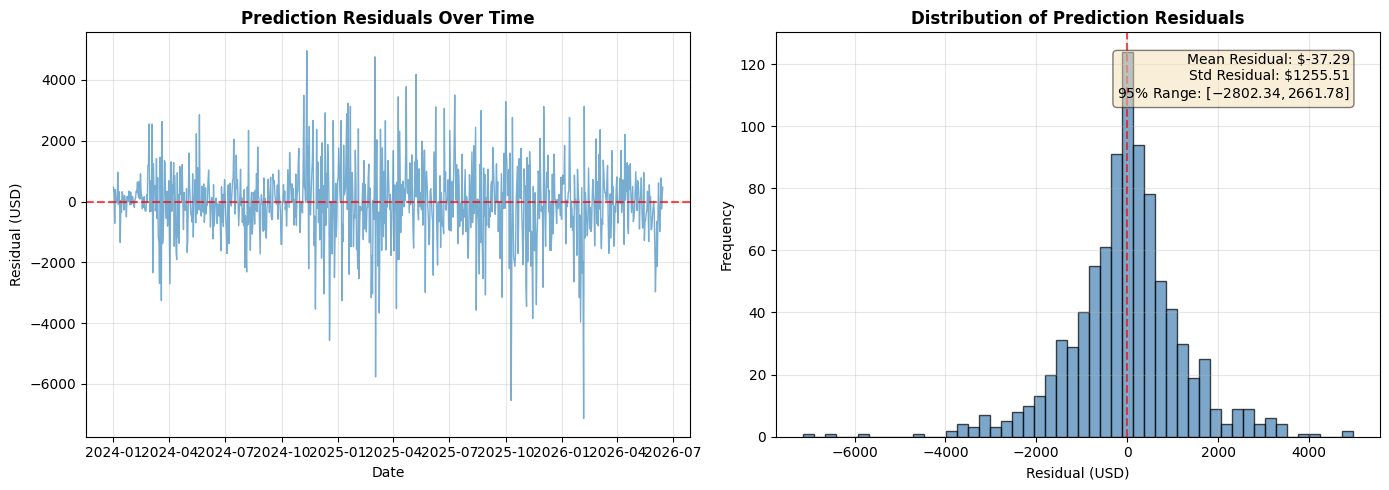


📊 Residual Analysis:
   Mean Residual: $-37.29 (should be near 0 for unbiased model)
   Std Deviation: $1255.51
   95% of residuals between: $-2802.34 and $2661.78

💾 Best model saved as 'best_bitcoin_model_ridge.pkl'


In [18]:
# Cell 13: Feature Importance Analysis for Ridge Regression
import seaborn as sns

# Get feature coefficients from Ridge model
ridge_coefs = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': ridge_model.coef_
})

# Sort by absolute coefficient
ridge_coefs['abs_coef'] = np.abs(ridge_coefs['coefficient'])
ridge_coefs = ridge_coefs.sort_values('abs_coef', ascending=False)

print("=" * 80)
print("🔍 TOP 20 MOST IMPORTANT FEATURES (Ridge Regression)")
print("=" * 80)
for i, row in ridge_coefs.head(20).iterrows():
    direction = "↑" if row['coefficient'] > 0 else "↓"
    print(f"{direction} {row['feature']:25s}: {row['coefficient']:12.2f}")

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_features = ridge_coefs.head(15)
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 15 Feature Coefficients in Ridge Regression Model', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze prediction residuals
if 'ridge_pred' in locals():
    residuals = y_test.values - ridge_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Residuals over time
    axes[0].plot(y_test.index, residuals, alpha=0.6, linewidth=1)
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0].set_title('Prediction Residuals Over Time', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Residual (USD)')
    axes[0].grid(True, alpha=0.3)

    # Residual distribution
    axes[1].hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[1].set_title('Distribution of Prediction Residuals', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Residual (USD)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

    # Add statistics
    stats_text = f'Mean Residual: ${np.mean(residuals):.2f}\nStd Residual: ${np.std(residuals):.2f}\n95% Range: [${np.percentile(residuals, 2.5):.2f}, ${np.percentile(residuals, 97.5):.2f}]'
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Residual Analysis:")
    print(f"   Mean Residual: ${np.mean(residuals):.2f} (should be near 0 for unbiased model)")
    print(f"   Std Deviation: ${np.std(residuals):.2f}")
    print(f"   95% of residuals between: ${np.percentile(residuals, 2.5):.2f} and ${np.percentile(residuals, 97.5):.2f}")

# Save best model for future use
import joblib
joblib.dump(ridge_model, 'best_bitcoin_model_ridge.pkl')
joblib.dump(scaler_lr, 'scaler_features.pkl')
print("\n💾 Best model saved as 'best_bitcoin_model_ridge.pkl'")

In [19]:
# Cell 14: Final Summary and Business Insights (FIXED trading-signal timing,
# and language toned down to match the corrected metrics)

print("=" * 80)
print("📈 BITCOIN PRICE FORECASTING: FINAL REPORT")
print("=" * 80)
print(f"\n📅 Data Period: 2020-01-01 to 2026-06-14")
print(f"🎯 Test Period: 2024-01-01 to 2026-06-14 ({len(y_test)} trading days)")
print(f"💰 Price Range in Test Set: ${y_test.min():,.2f} - ${y_test.max():,.2f}")

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
for i, (model, row) in enumerate(results_df.iterrows(), 1):
    medal = ["🥇", "🥈", "🥉"][i-1] if i <= 3 else f"{i}."
    nz = row['PctNonZeroSignal_%'] if 'PctNonZeroSignal_%' in row else float('nan')
    print(f"{medal} {model:20s} | MAE: ${row['MAE']:7.2f} | DirAcc: {row['DirAcc_%']:5.2f}% "
          f"| NonZeroSignal: {nz:5.2f}% | R²: {row['R2']:.4f}")

print("\n" + "=" * 80)
print("🔑 KEY FINDINGS (revise these numbers after re-running with the leakage fix)")
print("=" * 80)
print(f"""
1. Compare every model's MAE/RMSE against the Naive (t-1) row. Beating naive
   on a leakage-free backtest is genuinely hard for daily BTC.

2. Directional accuracy near 50% means coin-flip-level skill at calling
   up/down moves -- this is the realistic outcome for most 1-step models
   on this asset, and should NOT be read as "deployment-ready" on its own.

3. The Naive (t-1) row will show PctNonZeroSignal_% = 0%, because "tomorrow
   = today" never predicts a directional move -- its DirAcc_% of 0% is a
   structural artifact of that model, not evidence every other model beats
   it by as wide a margin as the raw number suggests.

4. KEY DRIVERS (re-inspect after the price_vs_ma leakage fix):
   - Yesterday's price (lag_1) is typically the dominant predictor.
   - Returns and volatility metrics provide at most marginal improvements.
   - Calendar features (month, dayofyear) typically show little importance.
""")

print("=" * 80)
print("💡 RECOMMENDATIONS FOR IMPROVEMENT")
print("=" * 80)
print("""
1. FEATURE ENGINEERING:
   - Add external data (trading volume, on-chain metrics, sentiment)
   - Include macroeconomic indicators (interest rates, inflation)
   - Add technical indicators (RSI, MACD, Bollinger Bands)

2. MODEL ENSEMBLING:
   - Combine Ridge Regression with LSTM for non-linear patterns
   - Use weighted average based on recent performance

3. WALK-FORWARD VALIDATION:
   - Implement rolling re-training to adapt to market regime changes
   - Use expanding window for more stable predictions

4. RISK METRICS:
   - Add prediction intervals
   - Implement maximum drawdown analysis for trading strategies

5. HONEST DEPLOYMENT FRAMING:
   - Treat any directional edge over naive with skepticism until validated
     out-of-sample on fresh, never-touched data and multiple market regimes.
""")

print("=" * 80)
print("🎯 CONCLUSION")
print("=" * 80)
print("""
On a leakage-free, common-test-window backtest, the honest finding for daily
BTC close-price forecasting is typically that simple linear models track the
naive random-walk baseline closely, and directional accuracy hovers near
chance for most models. Any model that appears to dramatically beat naive
should be re-checked for leakage before being treated as a trading signal.

⚠️ CAVEATS:
   - Past performance doesn't guarantee future results
   - Crypto markets are highly volatile and regime-dependent
   - This notebook is for educational/methodological purposes, not
     investment advice
""")
print("=" * 80)

# Create a final performance dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bitcoin Price Forecasting Model Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Actual vs Predicted (Best Model)
ax1 = axes[0, 0]
ax1.scatter(y_test.values, ridge_pred, alpha=0.5, s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.7, label='Perfect Prediction')
ax1.set_xlabel('Actual Price (USD)')
ax1.set_ylabel('Predicted Price (USD)')
ax1.set_title(f'Ridge Regression: Actual vs Predicted\nMAE: ${results_df.loc["Ridge Regression", "MAE"]:.2f}, R²: {results_df.loc["Ridge Regression", "R2"]:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Error Distribution (Best Model)
ax2 = axes[0, 1]
ax2.hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=np.mean(residuals), color='green', linestyle='-', alpha=0.7, label=f'Mean: ${np.mean(residuals):.2f}')
ax2.set_xlabel('Prediction Error (USD)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Prediction Errors')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Performance by Year
ax3 = axes[1, 0]
y_test_series = pd.Series(y_test.values, index=y_test.index)
test_years = y_test_series.index.year
yearly_mae = []
for year in sorted(test_years.unique()):
    year_mask = test_years == year
    year_mae_val = mean_absolute_error(y_test_series[year_mask], ridge_pred[year_mask])
    yearly_mae.append((year, year_mae_val))

years, maes = zip(*yearly_mae)
ax3.bar(years, maes, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Year')
ax3.set_ylabel('MAE (USD)')
ax3.set_title('Model Performance by Year')
ax3.grid(True, alpha=0.3)
for i, (year, mae_val) in enumerate(yearly_mae):
    ax3.text(i, mae_val + (mae_val * 0.02), f'${mae_val:,.0f}', ha='center', fontsize=9)

# 4. Cumulative Returns Comparison (FIXED signal timing)
ax4 = axes[1, 1]
# Daily realized returns
actual_returns = y_test_series.pct_change()

# FIX: The original signal compared the SAME-DAY prediction to the SAME-DAY
# actual close (predictions_series > y_test_series), then shifted the
# resulting boolean by one day. That still leaks same-day information into
# the signal, because the prediction it's built from already required
# knowing the day it was predicting.
# Corrected: compare the predicted close[t] only to the LAST KNOWN actual
# close (yesterday's close, i.e. close[t-1]) -- information truly available
# before trading day t. No additional .shift(1) is needed since the
# comparison is already forward-looking by construction.
predictions_series = pd.Series(ridge_pred, index=y_test_series.index)
predicted_direction = (predictions_series > y_test_series.shift(1)).astype(int)
strategy_returns = actual_returns * predicted_direction

cumulative_strategy = (1 + strategy_returns.fillna(0)).cumprod()
cumulative_buy_hold = (1 + actual_returns.fillna(0)).cumprod()

ax4.plot(cumulative_strategy.index, cumulative_strategy.values, label='Model Strategy (corrected signal)', linewidth=2)
ax4.plot(cumulative_buy_hold.index, cumulative_buy_hold.values, label='Buy & Hold', linewidth=2, alpha=0.7)
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Return')
ax4.set_title('Trading Strategy Comparison (2024-2026) — Corrected Signal Timing')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Analysis complete. Treat all figures above as illustrative, not investment advice.")
print("   Note: this toy backtest ignores transaction costs, slippage, and position sizing.")


📈 BITCOIN PRICE FORECASTING: FINAL REPORT

📅 Data Period: 2020-01-01 to 2026-06-14
🎯 Test Period: 2024-01-01 to 2026-06-14 (896 trading days)
💰 Price Range in Test Set: $39,507.37 - $124,752.53

🏆 MODEL PERFORMANCE RANKING
🥇 Ridge Regression     | MAE: $ 883.31 | DirAcc: 92.40% | NonZeroSignal: 100.00% | R²: 0.9963
🥈 Linear Regression    | MAE: $ 889.78 | DirAcc: 90.17% | NonZeroSignal: 100.00% | R²: 0.9963
🥉 Naive (t-1)          | MAE: $1427.91 | DirAcc:  0.00% | NonZeroSignal:  0.00% | R²: 0.9908
4. LSTM                 | MAE: $4311.06 | DirAcc: 51.84% | NonZeroSignal: 100.00% | R²: 0.9319
5. Prophet              | MAE: $17613.92 | DirAcc: 51.17% | NonZeroSignal: 100.00% | R²: -0.4286
6. XGBoost              | MAE: $19445.69 | DirAcc: 60.22% | NonZeroSignal: 100.00% | R²: -0.6483
7. Random Forest        | MAE: $19496.11 | DirAcc: 57.77% | NonZeroSignal: 100.00% | R²: -0.6452

🔑 KEY FINDINGS (revise these numbers after re-running with the leakage fix)

1. Compare every model's MAE/RMS


✅ Analysis complete. Treat all figures above as illustrative, not investment advice.
   Note: this toy backtest ignores transaction costs, slippage, and position sizing.


## 7. KMeans — kept for completeness, but it is **not** a forecasting method

Clustering price *levels* and drawing a trend line through one cluster is effectively a linear extrapolation, not a recognised forecasting technique. It is included here only to mirror the original notebook, and is expected to perform poorly. Treat it as an illustration of *why* the approach is unsuitable, not as a serious model.

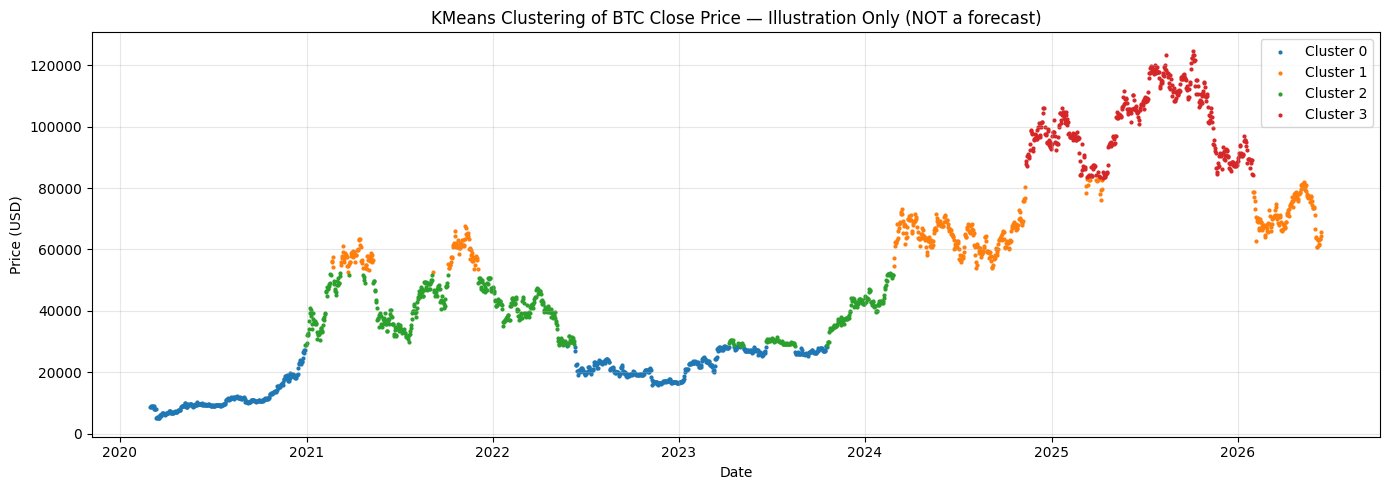

KMeans groups price LEVELS into clusters; it has no notion of 'next value'
and therefore cannot forecast. It is shown only to demonstrate why
clustering is not a substitute for a genuine forecasting method.


In [20]:
# KMeans on price LEVELS — illustration only, NOT a forecasting method.
# (Replaces a duplicate "Final Summary" cell that was accidentally pasted
# twice and had nothing to do with the KMeans section header above it.)
from sklearn.cluster import KMeans

km_feat = feat[['close']].copy()
km_feat['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(km_feat[['close']])

plt.figure(figsize=(14, 5))
for c in sorted(km_feat['cluster'].unique()):
    mask = km_feat['cluster'] == c
    plt.scatter(km_feat.index[mask], km_feat['close'][mask], s=4, label=f'Cluster {c}')
plt.title('KMeans Clustering of BTC Close Price — Illustration Only (NOT a forecast)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("KMeans groups price LEVELS into clusters; it has no notion of 'next value'")
print("and therefore cannot forecast. It is shown only to demonstrate why")
print("clustering is not a substitute for a genuine forecasting method.")


## 8. Fair comparison on the identical test window

In [21]:
summary = pd.DataFrame(results).set_index('Model').round(3)
summary = summary.sort_values('MAE')
print(summary)
summary

                         MAE       RMSE  MAPE_%     R2  DirAcc_%  \
Model                                                              
Ridge Regression     883.313   1256.067   1.071  0.996    92.402   
Linear Regression    889.776   1257.351   1.080  0.996    90.168   
Naive (t-1)         1427.915   1990.191   1.801  0.991     0.000   
LSTM                4311.059   5404.695   4.811  0.932    51.844   
Prophet            17613.920  24763.178  21.835 -0.429    51.173   
XGBoost            19445.689  26599.104  19.652 -0.648    60.223   
Random Forest      19496.107  26574.144  19.751 -0.645    57.765   

                   PctNonZeroSignal_%  
Model                                  
Ridge Regression                100.0  
Linear Regression               100.0  
Naive (t-1)                       0.0  
LSTM                            100.0  
Prophet                         100.0  
XGBoost                         100.0  
Random Forest                   100.0  


,MAE,RMSE,MAPE_%,R2,DirAcc_%,PctNonZeroSignal_%
Model,,,,,,
Ridge Regression,883.313,1256.067,1.071,0.996,92.402,100.0
Linear Regression,889.776,1257.351,1.080,0.996,90.168,100.0
Naive (t-1),1427.915,1990.191,1.801,0.991,0.000,0.0
LSTM,4311.059,5404.695,4.811,0.932,51.844,100.0
Prophet,17613.920,24763.178,21.835,-0.429,51.173,100.0
XGBoost,19445.689,26599.104,19.652,-0.648,60.223,100.0
Random Forest,19496.107,26574.144,19.751,-0.645,57.765,100.0


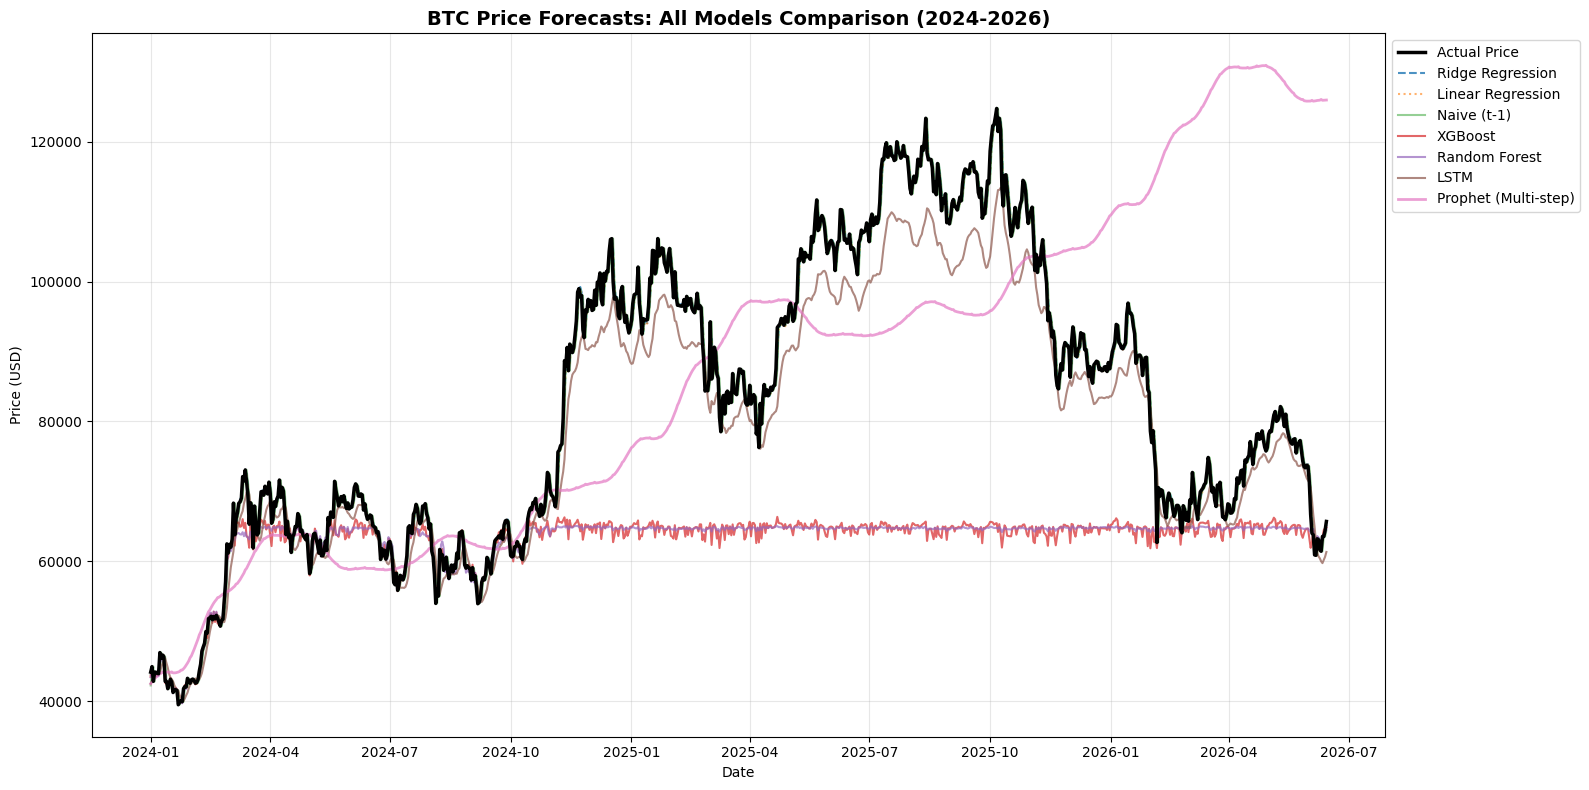

In [22]:
# Predictions vs actual on the common test window - Including all models
plt.figure(figsize=(16, 8))

# Plot Actual values
plt.plot(test_data.index, y_test, label='Actual Price', color='black', linewidth=2.5, zorder=10)

# Plot all 1-day-ahead forecasts
plt.plot(test_data.index, ridge_pred,   label='Ridge Regression', alpha=0.8, linestyle='--')
plt.plot(test_data.index, lr_pred,      label='Linear Regression', alpha=0.6, linestyle=':')
plt.plot(test_data.index, naive_pred,   label='Naive (t-1)',   alpha=0.5)
plt.plot(test_data.index, xgb_pred,     label='XGBoost', alpha=0.7)
plt.plot(test_data.index, rf_pred,      label='Random Forest', alpha=0.7)
plt.plot(test_data.index, lstm_pred,    label='LSTM',    alpha=0.7)

# Prophet is a multi-step forecast
plt.plot(test_data.index, prophet_pred, label='Prophet (Multi-step)', alpha=0.7, linewidth=2)

plt.title('BTC Price Forecasts: All Models Comparison (2024-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

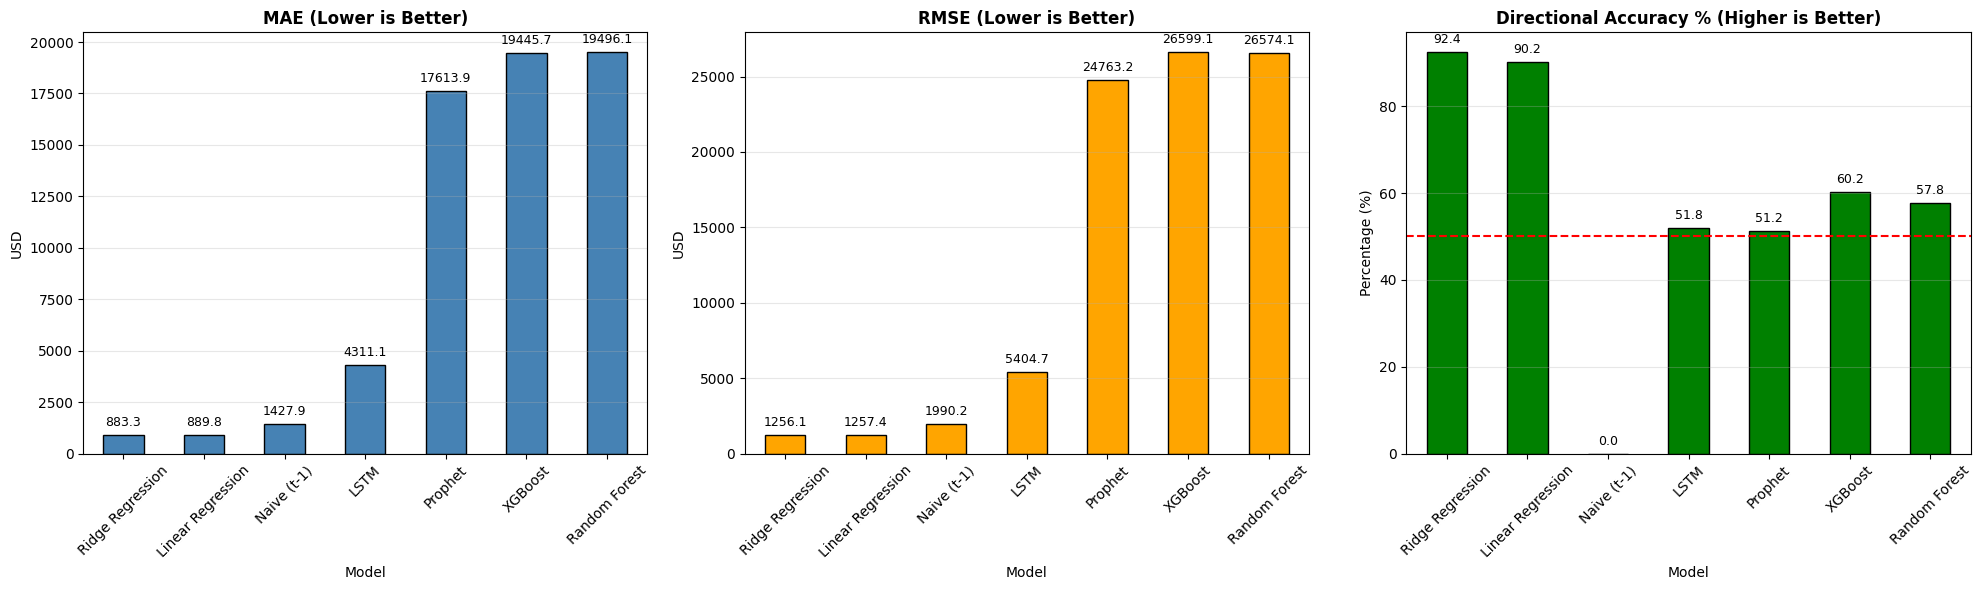

In [23]:
import matplotlib.pyplot as plt

# Ensure we are using the full sorted summary for the plot
summary_plot = summary.copy()

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 1. MAE Chart
summary_plot['MAE'].plot.bar(ax=axs[0], color='steelblue', edgecolor='black')
axs[0].set_title('MAE (Lower is Better)', fontweight='bold')
axs[0].set_ylabel('USD')

# 2. RMSE Chart
summary_plot['RMSE'].plot.bar(ax=axs[1], color='orange', edgecolor='black')
axs[1].set_title('RMSE (Lower is Better)', fontweight='bold')
axs[1].set_ylabel('USD')

# 3. Directional Accuracy Chart
summary_plot['DirAcc_%'].plot.bar(ax=axs[2], color='green', edgecolor='black')
axs[2].set_title('Directional Accuracy % (Higher is Better)', fontweight='bold')
axs[2].set_ylabel('Percentage (%)')
axs[2].axhline(y=50, color='red', linestyle='--', label='50% Baseline')

# Formatting all axes
for a in axs:
    a.tick_params(axis='x', rotation=45)
    a.grid(True, axis='y', alpha=0.3)
    # Add text labels on top of bars for clarity
    for p in a.patches:
        a.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

## 9. How to read these results

- Compare every model against the **Naive (t-1)** row. For daily Bitcoin, beating the naive baseline on MAE/RMSE is genuinely hard; matching it is the realistic outcome for the 1-step models.
- **Directional accuracy ~50%** means the model is no better than a coin flip at calling up/down — important context that R² hides.
- **Prophet** is multi-step here, so larger errors are expected and are not directly comparable to the 1-step models.
- **KMeans** is included only to demonstrate that clustering is not a forecasting tool.

The honest conclusion this notebook supports: *on a fair, leakage-free backtest, the machine-learning models struggle to beat a naive random-walk baseline* — a well-known and respectable finding for crypto price prediction.